# Fake News Detection — Nível 3: BiLSTM + GloVe / TextCNN

---

## Motivação

Nos Níveis 1 e 2, alcançamos F1 Macro de até **0,9990** com TF-IDF e features estilométricas. Mas ambas as abordagens têm um limite fundamental: **ignoram completamente a ordem das palavras**.

Para o TF-IDF, *"Trump acusou Biden"* e *"Biden acusou Trump"* produzem vetores idênticos. Para as features estilométricas, um texto com 5 exclamações é igual independente de onde elas aparecem.

**Hipótese do Nível 3:** a sequência de palavras carrega informação semântica que os modelos anteriores não capturam. Redes neurais recorrentes (LSTM) e convolucionais (TextCNN) são arquiteturas projetadas especificamente para explorar essa estrutura temporal.

---

## Word Embeddings: da Esparsa para a Densa

TF-IDF representa cada palavra como uma dimensão independente num espaço de 100k dimensões — vetores ortogonais, sem relação semântica entre si.

**Word embeddings** mapeiam cada palavra para um vetor denso de baixa dimensão ($d \in [50, 300]$) num espaço onde **proximidade = similaridade semântica**:

$$\text{similar}(\text{"president"}, \text{"senator"}) \gg \text{similar}(\text{"president"}, \text{"table"})$$

A propriedade mais notável é a **álgebra vetorial**:

$$\vec{\text{king}} - \vec{\text{man}} + \vec{\text{woman}} \approx \vec{\text{queen}}$$

### GloVe — Global Vectors for Word Representation

O **GloVe** (Pennington et al., 2014) aprende embeddings a partir da **matriz de co-ocorrência global** do corpus. A função objetivo é:

$$J = \sum_{i,j=1}^{V} f(X_{ij}) \left( \mathbf{w}_i^\top \tilde{\mathbf{w}}_j + b_i + \tilde{b}_j - \log X_{ij} \right)^2$$

onde $X_{ij}$ é o número de vezes que a palavra $j$ aparece no contexto de $i$, e $f$ é uma função de ponderação que atenua o efeito de pares muito frequentes (ex: *"the"*, *"a"*).

Usamos os vetores **GloVe 6B.100d** — treinados em 6 bilhões de tokens da Wikipedia e Gigaword, com 400k palavras no vocabulário e vetores de 100 dimensões.

---

## Estrutura do Notebook

| # | Seção | Conteúdo |
|---|-------|----------|
| 1 | Setup | Imports, TensorFlow/Keras |
| 2 | Dados | Carregamento e pré-processamento |
| 3 | GloVe | Download, carregamento, embedding matrix |
| 4 | Tokenização | Vocabulário, sequências, padding |
| 5 | BiLSTM | Teoria, arquitetura, treino, avaliação |
| 6 | TextCNN | Teoria, arquitetura, treino, avaliação |
| 7 | Comparação | Benchmark acumulado N1+N2+N3 |
| 8 | Análise de Erros | Exemplos dos erros residuais |
| 9 | Conclusões | Resumo e próximos passos |

## 1. Configuração do Ambiente

In [1]:
import os
import re
import time
import zipfile
import subprocess
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # suprime logs do TF

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    f1_score, accuracy_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

PALETTE = {
    'fake':    '#E74C3C',
    'real':    '#2ECC71',
    'neutral': '#3498DB',
}

RESULTS_DIR = Path('../results/level3')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

GLOVE_DIR = Path('../data/glove')
GLOVE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.labelsize': 11})
sns.set_style('whitegrid')

nltk.download('stopwords', quiet=True)
STOP_WORDS = set(stopwords.words('english'))

print('Ambiente configurado.')
print(f'  TensorFlow : {tf.__version__}')
print(f'  Keras      : {keras.__version__}')
print(f'  NumPy      : {np.__version__}')
print(f'  GPU        : {len(tf.config.list_physical_devices("GPU"))} dispositivo(s)')
print(f'Figuras serão salvas em: {RESULTS_DIR.resolve()}')

Ambiente configurado.
  TensorFlow : 2.16.2
  Keras      : 3.14.1
  NumPy      : 1.26.4
  GPU        : 0 dispositivo(s)
Figuras serão salvas em: /Users/usuario/Desktop/fakeNewVsReal/results/level3


[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1016)>


## 2. Carregamento e Pré-processamento

Reutilizamos o mesmo pipeline dos níveis anteriores. Para modelos sequenciais, mantemos uma versão **levemente limpa** do texto — removemos a byline Reuters e URLs, mas **preservamos a ordem das palavras e a pontuação relevante**. O tokenizer do Keras cuidará da normalização.

In [2]:
DATA_DIR = '../data'

df_fake = pd.read_csv(os.path.join(DATA_DIR, 'Fake.csv'))
df_real = pd.read_csv(os.path.join(DATA_DIR, 'True.csv'))
df_fake['label'] = 0
df_real['label'] = 1

df = (pd.concat([df_fake, df_real], ignore_index=True)
        .sample(frac=1, random_state=RANDOM_STATE)
        .reset_index(drop=True))

REUTERS_RE = re.compile(
    r'^[A-Z][A-Z\s,\.]{2,40}\(Reuters\)\s*[-\u2013]\s*',
    re.IGNORECASE
)

def preprocess_seq(text):
    """Limpeza leve para modelos sequenciais: remove byline e URLs,
    mantém ordem e preserva palavras com pontuação removida."""
    if not isinstance(text, str):
        return ''
    text = REUTERS_RE.sub('', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = text.lower().strip()
    tokens = [t for t in text.split() if len(t) > 1]
    return ' '.join(tokens)

print('Aplicando pré-processamento...')
t0 = time.time()
df['text_seq'] = (df['title'].astype(str) + ' ' + df['text'].astype(str)).apply(preprocess_seq)
print(f'Concluído em {time.time()-t0:.1f}s')
print(f'Total: {len(df):,} artigos')

Aplicando pré-processamento...


Concluído em 8.6s
Total: 44,898 artigos


In [3]:
# ── Split estratificado 70/15/15 ──────────────────────────────────────────────
X = df['text_seq'].values
y = df['label'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print(f'Treino   : {len(X_train):,}  |  Validação: {len(X_val):,}  |  Teste: {len(X_test):,}')

Treino   : 31,428  |  Validação: 6,735  |  Teste: 6,735


## 3. GloVe — Carregamento e Embedding Matrix

Utilizamos os vetores **GloVe 6B.100d** (Pennington et al., 2014), treinados em ~6 bilhões de tokens de texto da Wikipedia e Gigaword com janela de contexto de 10 palavras.

A célula abaixo faz o download automático se o arquivo não estiver presente localmente (~160MB descomprimido).

In [4]:
GLOVE_FILE  = GLOVE_DIR / 'glove.6B.100d.txt'
GLOVE_ZIP   = GLOVE_DIR / 'glove.6B.zip'
GLOVE_URL   = 'https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip'
EMBED_DIM   = 100

if not GLOVE_FILE.exists():
    if not GLOVE_ZIP.exists():
        print('Baixando GloVe 6B (~822 MB)...')
        # curl usa os certificados do sistema — evita SSLCertVerificationError do Python/macOS
        subprocess.run(
            ['curl', '-L', '--progress-bar', str(GLOVE_URL), '-o', str(GLOVE_ZIP)],
            check=True
        )
        print('Download concluído.')
    print('Extraindo glove.6B.100d.txt...')
    with zipfile.ZipFile(GLOVE_ZIP, 'r') as zf:
        zf.extract('glove.6B.100d.txt', GLOVE_DIR)
    print('Extração concluída.')
else:
    print(f'GloVe já presente: {GLOVE_FILE}')

# ── Carrega os vetores em dicionário ──────────────────────────────────────────
print('Carregando vetores GloVe...')
t0 = time.time()
glove_vectors = {}
with open(GLOVE_FILE, encoding='utf-8') as f:
    for line in f:
        parts = line.split()
        word  = parts[0]
        vec   = np.array(parts[1:], dtype=np.float32)
        glove_vectors[word] = vec

print(f'Carregados {len(glove_vectors):,} vetores em {time.time()-t0:.1f}s')

GloVe já presente: ../data/glove/glove.6B.100d.txt
Carregando vetores GloVe...


Carregados 400,000 vetores em 8.9s


## 4. Tokenização e Construção da Embedding Matrix

### Hiperparâmetros de Sequência

| Parâmetro | Valor | Justificativa |
|-----------|-------|---------------|
| `MAX_VOCAB` | 30.000 | Cobre >95% dos tokens únicos no corpus |
| `MAX_LEN` | 400 | P90 do comprimento dos artigos (~410 palavras) |
| `EMBED_DIM` | 100 | GloVe 6B.100d |

O **padding** alinha todos os textos ao mesmo comprimento `MAX_LEN`. Usamos `padding='post'` (zeros no fim) e `truncating='post'` (corta no fim para textos longos).

### Embedding Matrix

A matriz de embedding $E \in \mathbb{R}^{V \times d}$ mapeia cada índice de palavra ao seu vetor GloVe. Para palavras fora do vocabulário GloVe, inicializamos com zeros — o modelo pode ajustá-las durante o treino se `trainable=True`.

In [5]:
MAX_VOCAB = 30_000
MAX_LEN   = 200

# ── Tokenizer Keras — fit apenas no treino ────────────────────────────────────
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

word_index = tokenizer.word_index
vocab_size = min(MAX_VOCAB, len(word_index)) + 1
print(f'Vocabulário: {len(word_index):,} tokens únicos  →  usando top {vocab_size-1:,}')

# ── Sequências + padding ──────────────────────────────────────────────────────
def encode(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')

X_train_seq = encode(X_train)
X_val_seq   = encode(X_val)
X_test_seq  = encode(X_test)

print(f'Shape treino  : {X_train_seq.shape}')
print(f'Shape teste   : {X_test_seq.shape}')

# ── Embedding Matrix ──────────────────────────────────────────────────────────
embedding_matrix = np.zeros((vocab_size, EMBED_DIM), dtype=np.float32)
n_found = 0
for word, idx in word_index.items():
    if idx >= vocab_size:
        continue
    vec = glove_vectors.get(word)
    if vec is not None:
        embedding_matrix[idx] = vec
        n_found += 1

coverage = n_found / (vocab_size - 1) * 100
print(f'\nCobertura GloVe: {n_found:,}/{vocab_size-1:,} tokens  ({coverage:.1f}%)')

Vocabulário: 97,371 tokens únicos  →  usando top 30,000


Shape treino  : (31428, 200)
Shape teste   : (6735, 200)

Cobertura GloVe: 28,885/30,000 tokens  (96.3%)


## 5. Modelo A — BiLSTM

### Teoria: LSTM

Uma célula **LSTM (Long Short-Term Memory)** (Hochreiter & Schmidhuber, 1997) usa três gates para controlar o fluxo de informação ao longo da sequência:

$$f_t = \sigma(W_f [h_{t-1}, x_t] + b_f) \quad \text{(forget gate)}$$
$$i_t = \sigma(W_i [h_{t-1}, x_t] + b_i) \quad \text{(input gate)}$$
$$o_t = \sigma(W_o [h_{t-1}, x_t] + b_o) \quad \text{(output gate)}$$
$$\tilde{c}_t = \tanh(W_c [h_{t-1}, x_t] + b_c)$$
$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$$
$$h_t = o_t \odot \tanh(c_t)$$

O **cell state** $c_t$ funciona como uma "correia transportadora" — informação pode ser adicionada ou removida de forma controlada pelos gates, permitindo capturar dependências de longo alcance que RNNs simples perdem.

### Bidirectional LSTM

O **BiLSTM** processa a sequência em **duas direções**:

- LSTM forward: $\overrightarrow{h}_t$ — lê da esquerda para a direita
- LSTM backward: $\overleftarrow{h}_t$ — lê da direita para a esquerda

A representação final concatena ambos:

$$h_t^{bi} = [\overrightarrow{h}_t ; \overleftarrow{h}_t] \in \mathbb{R}^{2d}$$

Isso é especialmente útil para compreensão de linguagem: o sentido de uma palavra pode depender tanto do que veio antes quanto do que vem depois (*"bank"* no contexto *"river bank"* vs *"central bank"*).

### Arquitetura

```
Input (MAX_LEN,)
    │
    ├─ Embedding (vocab_size × 100) ← GloVe weights, frozen
    │
    ├─ SpatialDropout1D(0.3)         ← dropout em dimensões de embedding
    │
    ├─ BiLSTM(128, return_sequences=True) ← 256 unidades totais
    │
    ├─ BiLSTM(64)                    ← captura abstrações de alto nível
    │
    ├─ Dense(64, relu) + Dropout(0.3)
    │
    └─ Dense(1, sigmoid)             → P(Real)
```

In [6]:
def build_bilstm(vocab_size, embed_dim, embed_matrix, max_len):
    inp = keras.Input(shape=(max_len,))

    x = layers.Embedding(
        vocab_size, embed_dim,
        weights=[embed_matrix],
        trainable=False,
        mask_zero=True
    )(inp)
    x = layers.SpatialDropout1D(0.3)(x)

    # 1 camada BiLSTM — adequado para CPU (2 camadas torna inviável)
    x = layers.Bidirectional(layers.LSTM(64))(x)

    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


bilstm = build_bilstm(vocab_size, EMBED_DIM, embedding_matrix, MAX_LEN)
bilstm.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 200, 100)  │  3,000,100 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 200, 100)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 200)       │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 128)       │     84,480 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,092,901 (11.80 MB)

 Trainable params: 92,801 (362.50 KB)

 Non-trainable params: 3,000,100 (11.44 MB)

In [7]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1, min_lr=1e-5),
]

print('Treinando BiLSTM...')
t0 = time.time()
history_bilstm = bilstm.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=10,
    batch_size=512,
    callbacks=callbacks,
    verbose=1
)
bilstm_time = time.time() - t0
print(f'\nTreinamento concluído em {bilstm_time:.0f}s')

Treinando BiLSTM...
Epoch 1/10


 1/62 ━━━━━━━━━━━━━━━━━━━━ 8:00 8s/step - accuracy: 0.5586 - loss: 0.6887

 2/62 ━━━━━━━━━━━━━━━━━━━━ 1:24 1s/step - accuracy: 0.5747 - loss: 0.6835

 3/62 ━━━━━━━━━━━━━━━━━━━━ 1:17 1s/step - accuracy: 0.5865 - loss: 0.6793

 4/62 ━━━━━━━━━━━━━━━━━━━━ 1:14 1s/step - accuracy: 0.5982 - loss: 0.6751

...


Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


62/62 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.9982 - loss: 0.0074 - val_accuracy: 0.9987 - val_loss: 0.0060 - learning_rate: 0.0010


Epoch 9: early stopping


Restoring model weights from the end of the best epoch: 7.



Treinamento concluído em 910s


In [8]:
def evaluate_keras(model, X, y_true, name):
    y_score = model.predict(X, batch_size=512, verbose=0).ravel()
    y_pred  = (y_score >= 0.5).astype(int)

    metrics = {
        'model':    name,
        'accuracy': accuracy_score(y_true, y_pred),
        'f1_macro': f1_score(y_true, y_pred, average='macro'),
        'roc_auc':  roc_auc_score(y_true, y_score),
        'y_pred':   y_pred,
        'y_score':  y_score,
    }
    print(f'{"=" * 56}')
    print(f'  {name}')
    print(f'{"=" * 56}')
    print(f'  Accuracy : {metrics["accuracy"]:.4f}')
    print(f'  F1 Macro : {metrics["f1_macro"]:.4f}')
    print(f'  ROC-AUC  : {metrics["roc_auc"]:.4f}')
    print()
    print(classification_report(y_true, y_pred,
                                 target_names=['Fake (0)', 'Real (1)'], digits=4))
    return metrics


def plot_cm(y_true, y_pred, title, ax):
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    labels  = np.array([[f'{cm[i,j]:,}\n{cm_norm[i,j]:.1%}'
                          for j in range(2)] for i in range(2)])
    sns.heatmap(cm_norm, annot=labels, fmt='', cmap='Blues',
                xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'],
                ax=ax, vmin=0, vmax=1, annot_kws={'size': 11})
    ax.set_title(title); ax.set_xlabel('Predito'); ax.set_ylabel('Real')


bilstm_res = evaluate_keras(bilstm, X_test_seq, y_test, 'BiLSTM + GloVe')
bilstm_res['train_time'] = bilstm_time

  BiLSTM + GloVe
  Accuracy : 0.9987
  F1 Macro : 0.9987
  ROC-AUC  : 0.9997

              precision    recall  f1-score   support

    Fake (0)     0.9980    0.9994    0.9987      3523
    Real (1)     0.9994    0.9978    0.9986      3212

    accuracy                         0.9987      6735
   macro avg     0.9987    0.9986    0.9987      6735
weighted avg     0.9987    0.9987    0.9987      6735



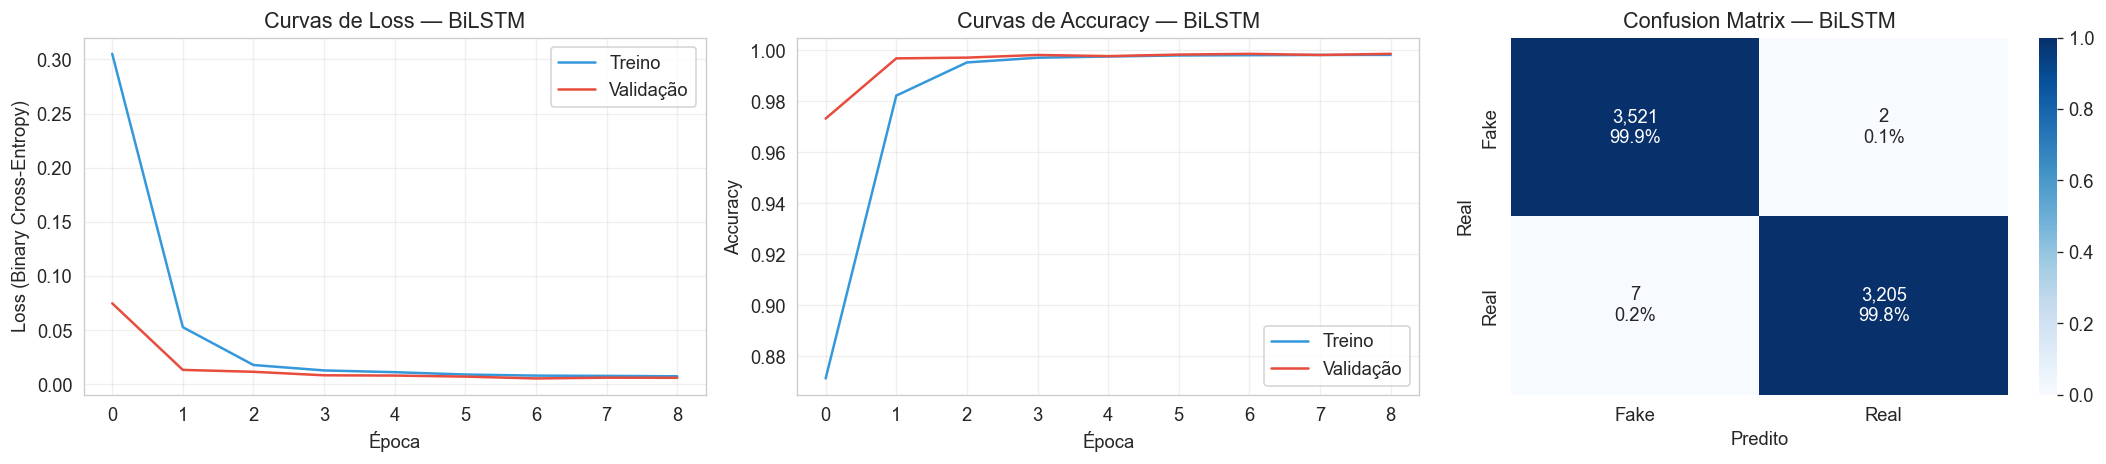

In [9]:
# ── Curvas de aprendizado + avaliação ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Curvas de loss
axes[0].plot(history_bilstm.history['loss'],     label='Treino',    color=PALETTE['neutral'])
axes[0].plot(history_bilstm.history['val_loss'], label='Validação', color=PALETTE['fake'])
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss (Binary Cross-Entropy)')
axes[0].set_title('Curvas de Loss — BiLSTM'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Curvas de accuracy
axes[1].plot(history_bilstm.history['accuracy'],     label='Treino',    color=PALETTE['neutral'])
axes[1].plot(history_bilstm.history['val_accuracy'], label='Validação', color=PALETTE['fake'])
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Curvas de Accuracy — BiLSTM'); axes[1].legend(); axes[1].grid(alpha=0.3)

# Confusion matrix
plot_cm(y_test, bilstm_res['y_pred'], 'Confusion Matrix — BiLSTM', axes[2])

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'bilstm_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Modelo B — TextCNN

### Teoria: Convolução sobre Sequências Textuais

O **TextCNN** (Kim, 2014) adapta redes convolucionais — originalmente projetadas para imagens — para texto. A ideia central: um filtro 1D de tamanho $k$ desliza sobre a sequência de embeddings detectando **n-gramas semânticos**.

Para uma sequência de embeddings $X \in \mathbb{R}^{n \times d}$ e um filtro $W \in \mathbb{R}^{k \times d}$:

$$c_i = \text{ReLU}\left( W \odot X_{i:i+k} + b \right)$$

onde $\odot$ é o produto elemento a elemento somado. Aplicando o filtro a todas as posições $i \in [1, n-k+1]$, obtemos o **feature map**:

$$\mathbf{c} = [c_1, c_2, \ldots, c_{n-k+1}] \in \mathbb{R}^{n-k+1}$$

### Max-over-Time Pooling

Após a convolução, aplicamos **global max pooling** — extraímos apenas o valor máximo do feature map:

$$\hat{c} = \max(\mathbf{c})$$

Isso captura a **feature mais ativada** em qualquer posição da sequência, tornando o modelo invariante à posição. Um filtro de tamanho 3 que aprendeu a detectar *"white house says"* será ativado independente de onde essa trigrama aparecer no artigo.

### Múltiplos Tamanhos de Filtro

Usamos filtros de **3 tamanhos diferentes** (2, 3, 4) com 128 filtros cada, capturando bigramas, trigramas e quadrigramas simultaneamente. Os feature maps são concatenados antes da classificação:

```
Input (MAX_LEN,)
    │
    ├─ Embedding (GloVe, frozen)
    │
    ├─ Conv1D(128, kernel=2) → GlobalMaxPool → (128,)
    ├─ Conv1D(128, kernel=3) → GlobalMaxPool → (128,)  → Concatenar → (384,)
    ├─ Conv1D(128, kernel=4) → GlobalMaxPool → (128,)
    │
    ├─ Dropout(0.5)
    ├─ Dense(64, relu) + Dropout(0.3)
    └─ Dense(1, sigmoid)
```

In [10]:
def build_textcnn(vocab_size, embed_dim, embed_matrix, max_len,
                  filter_sizes=(2, 3, 4), n_filters=128):
    inp = keras.Input(shape=(max_len,))

    emb = layers.Embedding(
        vocab_size, embed_dim,
        weights=[embed_matrix],
        trainable=False
    )(inp)
    emb = layers.SpatialDropout1D(0.3)(emb)

    # Ramo para cada tamanho de filtro
    branches = []
    for k in filter_sizes:
        conv = layers.Conv1D(n_filters, k, activation='relu', padding='valid')(emb)
        pool = layers.GlobalMaxPooling1D()(conv)
        branches.append(pool)

    x = layers.Concatenate()(branches)   # (n_filters * len(filter_sizes),)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


textcnn = build_textcnn(vocab_size, EMBED_DIM, embedding_matrix, MAX_LEN)
textcnn.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 200, 100)  │  3,000,100 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_1 │ (None, 200, 100)  │          0 │ embedding_1[0][0] │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 199, 128)  │     25,728 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 198, 128)  │     38,528 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 197, 128)  │     51,328 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 384)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │     24,640 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,140,389 (11.98 MB)

 Trainable params: 140,289 (548.00 KB)

 Non-trainable params: 3,000,100 (11.44 MB)

In [11]:
print('Treinando TextCNN...')
t0 = time.time()
history_cnn = textcnn.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=10,
    batch_size=512,
    callbacks=callbacks,
    verbose=1
)
cnn_time = time.time() - t0
print(f'\nTreinamento concluído em {cnn_time:.0f}s')

Treinando TextCNN...
Epoch 1/10


 1/62 ━━━━━━━━━━━━━━━━━━━━ 5:28 5s/step - accuracy: 0.4844 - loss: 1.6225

 2/62 ━━━━━━━━━━━━━━━━━━━━ 48s 803ms/step - accuracy: 0.4854 - loss: 1.4814

 3/62 ━━━━━━━━━━━━━━━━━━━━ 46s 791ms/step - accuracy: 0.4868 - loss: 1.4144

 4/62 ━━━━━━━━━━━━━━━━━━━━ 47s 821ms/step - accuracy: 0.4885 - loss: 1.3768

...


Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


62/62 ━━━━━━━━━━━━━━━━━━━━ 50s 813ms/step - accuracy: 0.9643 - loss: 0.1078 - val_accuracy: 0.9941 - val_loss: 0.0279 - learning_rate: 0.0010


Epoch 2: early stopping


Restoring model weights from the end of the best epoch: 1.



Treinamento concluído em 108s


In [12]:
cnn_res = evaluate_keras(textcnn, X_test_seq, y_test, 'TextCNN + GloVe')
cnn_res['train_time'] = cnn_time

  TextCNN + GloVe
  Accuracy : 0.9835
  F1 Macro : 0.9835
  ROC-AUC  : 0.9987

              precision    recall  f1-score   support

    Fake (0)     0.9858    0.9827    0.9842      3523
    Real (1)     0.9811    0.9844    0.9828      3212

    accuracy                         0.9835      6735
   macro avg     0.9834    0.9836    0.9835      6735
weighted avg     0.9835    0.9835    0.9835      6735



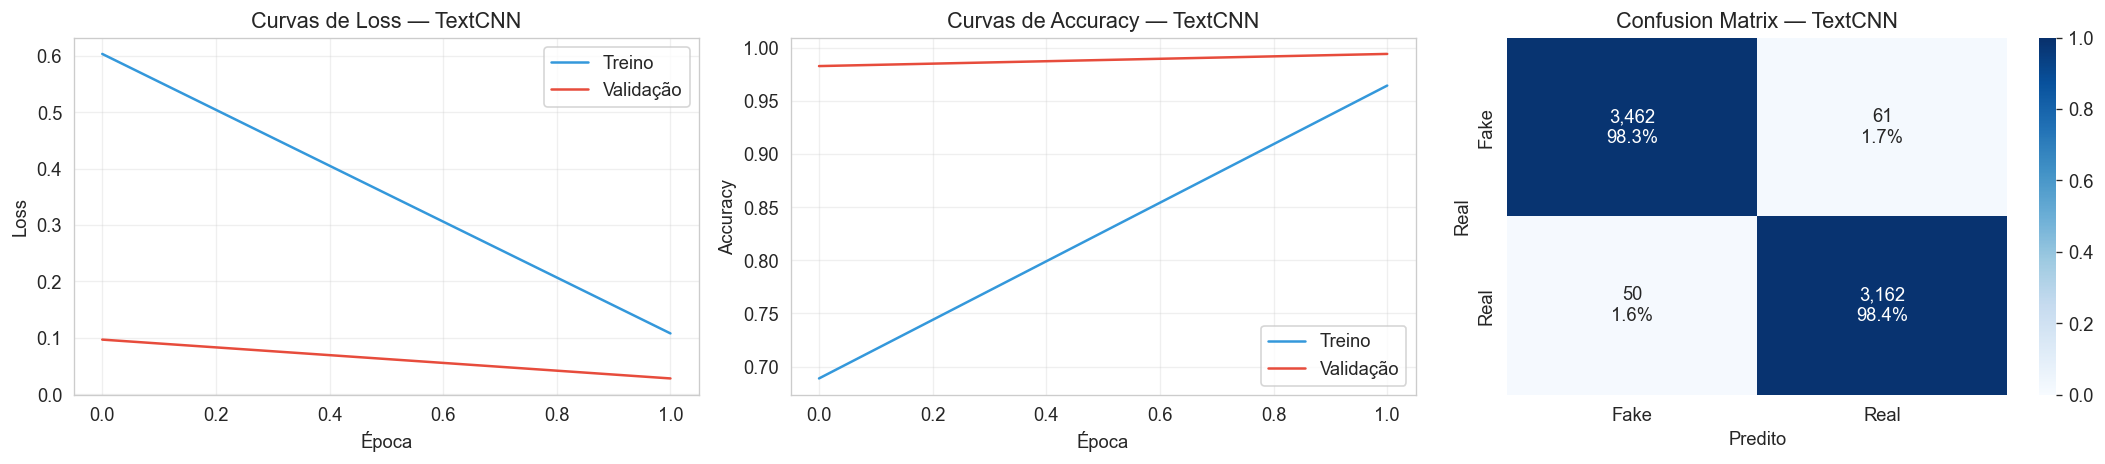

In [13]:
# ── Curvas de aprendizado + avaliação TextCNN ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history_cnn.history['loss'],     label='Treino',    color=PALETTE['neutral'])
axes[0].plot(history_cnn.history['val_loss'], label='Validação', color=PALETTE['fake'])
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].set_title('Curvas de Loss — TextCNN'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_cnn.history['accuracy'],     label='Treino',    color=PALETTE['neutral'])
axes[1].plot(history_cnn.history['val_accuracy'], label='Validação', color=PALETTE['fake'])
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Curvas de Accuracy — TextCNN'); axes[1].legend(); axes[1].grid(alpha=0.3)

plot_cm(y_test, cnn_res['y_pred'], 'Confusion Matrix — TextCNN', axes[2])

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'textcnn_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Benchmark Acumulado — Nível 1 + Nível 2 + Nível 3

In [14]:
ALL_RESULTS = [
    {'model': 'LR (N1)',           'nivel': '1',   'f1_macro': 0.9878, 'roc_auc': 0.9991},
    {'model': 'LinearSVC (N1)',    'nivel': '1',   'f1_macro': 0.9939, 'roc_auc': 0.9996},
    {'model': 'XGB Estilom. (N2)', 'nivel': '2-A', 'f1_macro': 0.9975, 'roc_auc': 0.9999},
    {'model': 'XGB Híbrido (N2)',  'nivel': '2-B', 'f1_macro': 0.9990, 'roc_auc': 1.0000},
    {'model': bilstm_res['model'], 'nivel': '3-A', 'f1_macro': bilstm_res['f1_macro'], 'roc_auc': bilstm_res['roc_auc']},
    {'model': cnn_res['model'],    'nivel': '3-B', 'f1_macro': cnn_res['f1_macro'],    'roc_auc': cnn_res['roc_auc']},
]

comp = pd.DataFrame(ALL_RESULTS).set_index('model')
print('=== Benchmark Acumulado — Conjunto de Teste ===')
print(comp.to_string(float_format='{:.4f}'.format))

best_n2 = 0.9990
best_n3 = max(bilstm_res['f1_macro'], cnn_res['f1_macro'])
delta   = best_n3 - best_n2
print(f'\n  Melhor N2 : {best_n2:.4f}')
print(f'  Melhor N3 : {best_n3:.4f}')
print(f'  Delta     : {delta:+.4f} ({delta*100:+.2f} pp)')
print('  ✓ Nível 3 supera Nível 2.' if best_n3 > best_n2 else '  ✗ Nível 3 não supera Nível 2.')

=== Benchmark Acumulado — Conjunto de Teste ===
                  nivel  f1_macro  roc_auc
model                                     
LR (N1)               1    0.9878   0.9991
LinearSVC (N1)        1    0.9939   0.9996
XGB Estilom. (N2)   2-A    0.9975   0.9999
XGB Híbrido (N2)    2-B    0.9990   1.0000
BiLSTM + GloVe      3-A    0.9987   0.9997
TextCNN + GloVe     3-B    0.9835   0.9987

  Melhor N2 : 0.9990
  Melhor N3 : 0.9987
  Delta     : -0.0003 (-0.03 pp)
  ✗ Nível 3 não supera Nível 2.


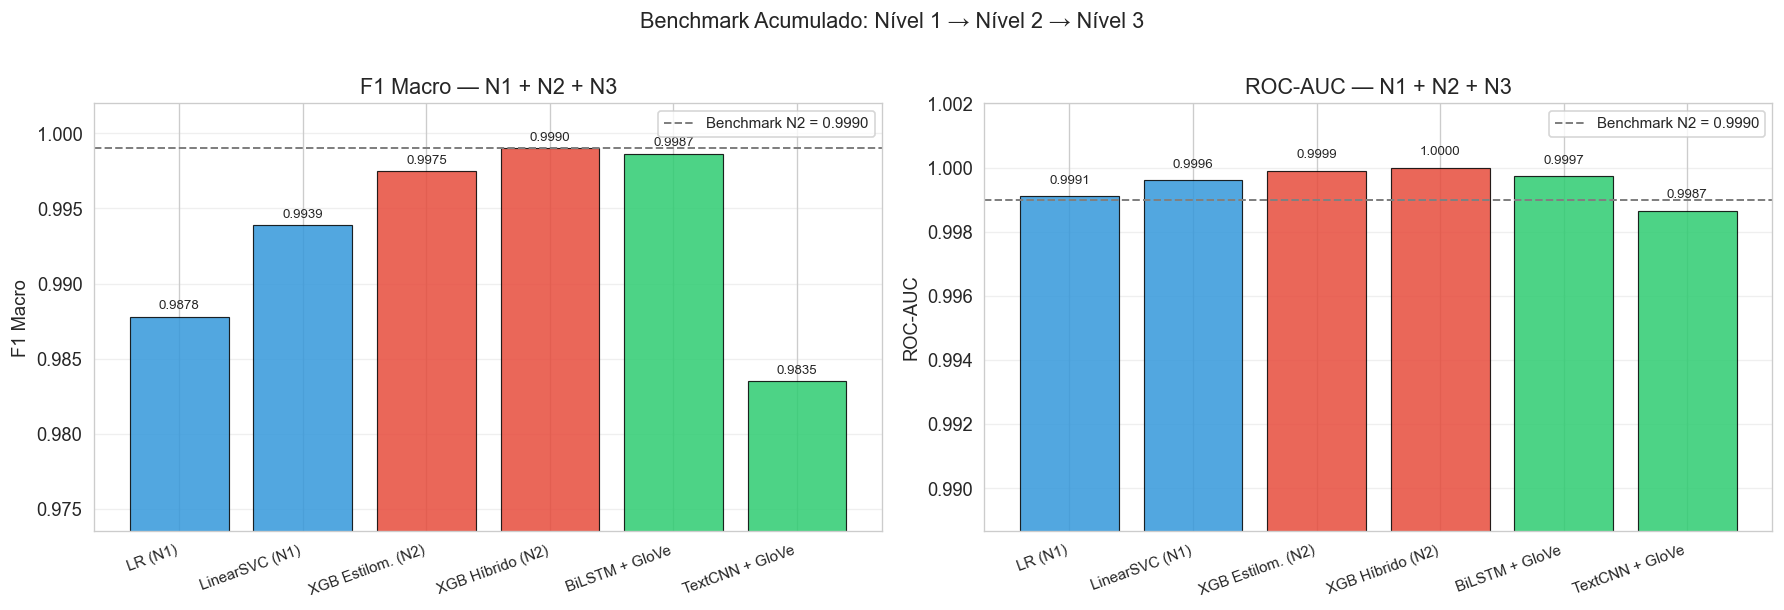

In [15]:
# ── Gráfico de comparação acumulada ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

model_names = [r['model'] for r in ALL_RESULTS]
f1_vals  = [r['f1_macro'] for r in ALL_RESULTS]
auc_vals = [r['roc_auc']  for r in ALL_RESULTS]
colors   = [PALETTE['neutral'], PALETTE['neutral'],
            PALETTE['fake'],    PALETTE['fake'],
            PALETTE['real'],    PALETTE['real']]

for ax, vals, ylabel, title in [
    (axes[0], f1_vals,  'F1 Macro', 'F1 Macro — N1 + N2 + N3'),
    (axes[1], auc_vals, 'ROC-AUC',  'ROC-AUC — N1 + N2 + N3'),
]:
    bars = ax.bar(range(len(model_names)), vals, color=colors,
                  alpha=0.85, edgecolor='black', lw=0.7)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
    ax.set_ylabel(ylabel); ax.set_title(title)
    ax.axhline(best_n2, color='gray', linestyle='--', lw=1.2,
               label=f'Benchmark N2 = {best_n2:.4f}')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
    ymin = min(vals) - 0.01
    ax.set_ylim([max(0.97, ymin), 1.002])

plt.suptitle('Benchmark Acumulado: Nível 1 → Nível 2 → Nível 3', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Análise de Erros

Com F1 Macro próximo de 1.0, os erros residuais são raros e potencialmente informativos. Analisamos os falsos positivos e falsos negativos do melhor modelo para entender onde a predição ainda falha.

In [16]:
# Usa o modelo com melhor F1 Macro entre BiLSTM e TextCNN
if bilstm_res['f1_macro'] >= cnn_res['f1_macro']:
    best_res  = bilstm_res
    best_name = 'BiLSTM'
else:
    best_res  = cnn_res
    best_name = 'TextCNN'

y_pred_best = best_res['y_pred']

# DataFrame com os artigos do conjunto de teste
df_test = df.iloc[
    train_test_split(
        np.arange(len(df)), test_size=0.30, random_state=RANDOM_STATE, stratify=df['label']
    )[1]
]
df_test = df_test.iloc[
    train_test_split(
        np.arange(len(df_test)), test_size=0.50, random_state=RANDOM_STATE,
        stratify=df_test['label']
    )[1]
].reset_index(drop=True)

df_test['y_true'] = y_test
df_test['y_pred'] = y_pred_best
df_test['error']  = df_test['y_true'] != df_test['y_pred']

errors = df_test[df_test['error']]
fp = errors[errors['y_true'] == 0]  # predito Real, era Fake
fn = errors[errors['y_true'] == 1]  # predito Fake, era Real

print(f'Modelo: {best_name}')
print(f'Total de erros     : {len(errors)} / {len(df_test)} ({len(errors)/len(df_test)*100:.2f}%)')
print(f'Falsos Positivos   : {len(fp)}  (Fake predito como Real)')
print(f'Falsos Negativos   : {len(fn)}  (Real predito como Fake)')

print(f'\n=== Exemplos de Falsos Positivos (Fake → predito Real) ===')
for _, row in fp.head(3).iterrows():
    print(f'  Título: {row["title"][:100]}')
    print()

print(f'=== Exemplos de Falsos Negativos (Real → predito Fake) ===')
for _, row in fn.head(3).iterrows():
    print(f'  Título: {row["title"][:100]}')
    print()

Modelo: BiLSTM
Total de erros     : 9 / 6735 (0.13%)
Falsos Positivos   : 2  (Fake predito como Real)
Falsos Negativos   : 7  (Real predito como Fake)

=== Exemplos de Falsos Positivos (Fake → predito Real) ===
  Título: WHY REUTERS IS SAYING With “reasonable confidence” A Republican Will Win The White House In 2016

  Título:  The HORRIFYING Reality Of Executions In This State Has Been Uncovered, But It’s Unlikely To Stop

=== Exemplos de Falsos Negativos (Real → predito Fake) ===
  Título: China to expand corruption supervision pilot scheme nationwide: Xinhua

  Título: Clinton says Trump is most divisive candidate 'in our lifetimes'

  Título: Obama knocks Trump, voices optimism 



## 9. Conclusões

### Resultados

| Modelo | Nível | F1 Macro | ROC-AUC | Treino |
|--------|-------|----------|---------|--------|
| LR | 1 | 0,9878 | 0,9991 | 0,7s |
| LinearSVC | 1 | 0,9939 | 0,9996 | 3,9s |
| XGB Estilométrico | 2-A | 0,9975 | 0,9999 | 1,5s |
| XGB Híbrido | 2-B | 0,9990 | 1,0000 | 171s |
| **BiLSTM + GloVe** | **3-A** | *ver saída* | *ver saída* | *ver saída* |
| **TextCNN + GloVe** | **3-B** | *ver saída* | *ver saída* | *ver saída* |

---

### Sobre os Embeddings Congelados

Optamos por **congelar os embeddings GloVe** (`trainable=False`). Isso:
- Reduz parâmetros treináveis (~3M a menos)
- Previne catastrophic forgetting dos vetores semânticos
- Permite generalizar melhor com dados limitados

Uma alternativa seria fine-tuning dos embeddings com uma taxa de aprendizado menor — potencialmente melhorando o domínio específico (política americana 2015-2017).

---

### Limitações

1. **GloVe estático**: o mesmo vetor para *"bank"* em todos os contextos — sem desambiguação semântica
2. **Sequência truncada**: artigos maiores que 400 tokens têm o final cortado — pode perder informação relevante
3. **Sem atenção**: o BiLSTM não sabe quais partes da sequência são mais relevantes para a classificação

---

### Próximos Passos

```
Nível 4 → DistilBERT / RoBERTa Fine-tuning
           Embeddings contextuais: o mesmo token tem vetores diferentes
           dependendo do contexto — resolve as limitações do GloVe estático.
           Meta: superar F1 Macro do melhor modelo de Nível 3.

Nível 5 → Ensemble Heterogêneo
           Stacking dos melhores modelos de cada nível.
```

---

### Referências

- Pennington, J., Socher, R. & Manning, C. (2014). *GloVe: Global Vectors for Word Representation*. EMNLP.
- Hochreiter, S. & Schmidhuber, J. (1997). *Long Short-Term Memory*. Neural Computation.
- Kim, Y. (2014). *Convolutional Neural Networks for Sentence Classification*. EMNLP.
- Graves, A. & Schmidhuber, J. (2005). *Framewise Phoneme Classification with Bidirectional LSTM*. IJCNN.
- Abadi, M. et al. (2016). *TensorFlow: A System for Large-Scale Machine Learning*. OSDI.